In [3]:
import os
import pandas as pd
import torch
import numpy as np
import timm
from PIL import Image
import cv2
import matplotlib.pyplot as plt

from torchvision import transforms
from captum.attr import LayerGradCam
from captum.attr import visualization as viz

C:\Users\epsilon\anaconda3\envs\explainable_ai\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1.Definir PATH

In [15]:
DATA_PATH = "winner_data/"
METADATA_PATH = os.path.join(DATA_PATH, "metadata/")
IMAGES_PATH = os.path.join(DATA_PATH, "images/")
MODELS_PATH = "models/"
FIGURES_PATH = "figures"

EXPERIMENT_NAME = "edgenext_last_layer/"
MODEL_SAVE_PATH = os.path.join(MODELS_PATH, EXPERIMENT_NAME)
BEST_MODEL_FILENAME = "edgenext_best.pth"
BEST_MODEL_FULL_PATH = os.path.join(MODEL_SAVE_PATH, BEST_MODEL_FILENAME)

VAL_DF_FILENAME = "val.csv"
VAL_DF_PATH = os.path.join(METADATA_PATH, VAL_DF_FILENAME)

IMAGE_PATH_COL = "image_path"
TARGET_COL = "target"

MODEL_NAME = 'edgenext_base.in21k_ft_in1k'
NUM_CLASSES = 2

if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
else:
    DEVICE = torch.device("cpu")

print(f"Device: {DEVICE}")
print(f"Path modelo: {BEST_MODEL_FULL_PATH}")
print(f"Path csv validacion: {VAL_DF_PATH}")
print(f"Arquitectura: {MODEL_NAME}")

Device: cuda
Path modelo: models/edgenext_last_layer/edgenext_best.pth
Path csv validacion: winner_data/metadata/val.csv
Arquitectura: edgenext_base.in21k_ft_in1k


## 2. Transformaciones imagenes

In [5]:
# Definir transformaciones imagenes validacion
model_cfg = timm.get_pretrained_cfg(MODEL_NAME)
IMG_SIZE = model_cfg.input_size[1]
NORM_MEAN = model_cfg.mean
NORM_STD = model_cfg.std

val_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=NORM_MEAN, std=NORM_STD),
])
print(f"Tamaño imagen: {IMG_SIZE}x{IMG_SIZE}")
print(f"Media normalizada: {NORM_MEAN}")
print(f"Desv estandar normalizada: {NORM_STD}")

Tamaño imagen: 256x256
Media normalizada: (0.485, 0.456, 0.406)
Desv estandar normalizada: (0.229, 0.224, 0.225)


## 3. Cargar modelo preentrenado y data validación

In [6]:
# Cargar modelo. Pretrained = False para cargar nuestros pesos
explanation_model = timm.create_model(MODEL_NAME, pretrained=False, num_classes=NUM_CLASSES)

# Cargar pesos de nuestro entrenamiento
explanation_model.load_state_dict(torch.load(BEST_MODEL_FULL_PATH, map_location=DEVICE))
explanation_model = explanation_model.to(DEVICE)

# Colocar modelo en modo evaluacion (evita calculo de gradientes)
explanation_model.eval()

EdgeNeXt(
  (stem): Sequential(
    (0): Conv2d(3, 80, kernel_size=(4, 4), stride=(4, 4))
    (1): LayerNorm2d((80,), eps=1e-06, elementwise_affine=True)
  )
  (stages): Sequential(
    (0): EdgeNeXtStage(
      (downsample): Identity()
      (blocks): Sequential(
        (0): ConvBlock(
          (conv_dw): Conv2d(80, 80, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=80)
          (norm): LayerNorm((80,), eps=1e-06, elementwise_affine=True)
          (mlp): Mlp(
            (fc1): Linear(in_features=80, out_features=320, bias=True)
            (act): GELU(approximate='none')
            (drop1): Dropout(p=0.0, inplace=False)
            (norm): Identity()
            (fc2): Linear(in_features=320, out_features=80, bias=True)
            (drop2): Dropout(p=0.0, inplace=False)
          )
          (drop_path): Identity()
        )
        (1): ConvBlock(
          (conv_dw): Conv2d(80, 80, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=80)
          (norm): Layer

In [7]:
# Cargar data val
val_df = pd.read_csv(VAL_DF_PATH)
val_df.head(5)

,isic_id,target,image_path
0,ISIC_4260773,0,winner_data/images/original/ISIC_4260773.jpg
1,ISIC_9697201,0,winner_data/images/original/ISIC_9697201.jpg
2,ISIC_8301065,0,winner_data/images/original/ISIC_8301065.jpg
3,ISIC_3753800,0,winner_data/images/original/ISIC_3753800.jpg
4,ISIC_0690097,0,winner_data/images/original/ISIC_0690097.jpg


## 4. Ejemplos GradCam

In [29]:
# Funcion auxiliar para gradcam
def visualize_gradcam(model, target_layer, input_tensor, original_image_np, true_label=None, save_path=None):
    model.eval()
    layer_gradcam = LayerGradCam(model, target_layer)

    output = model(input_tensor.to(DEVICE))
    # Obtener probabilidades de cada clase y seleccionar
    # el indice 0 o 1 de la mas probable
    probabilities = torch.nn.functional.softmax(output, dim=1)
    pred_prob, pred_label_idx = torch.topk(probabilities, 1)
    
    predicted_class = pred_label_idx.item()
    if predicted_class == 1:
        prediction_text = "Maligno"
    else:
        prediction_text = "Benigno"
    
    print(f"Clase predicha: {predicted_class} ({prediction_text})")
    print(f"Prob: {pred_prob.item():.4f}")

    if predicted_class == true_label:
        is_correct = "Prediccion correcta"
    else:
        is_correct = "Prediccion incorrecta"
    print(f"Ground Truth: {true_label} || {is_correct}")

    attribution = layer_gradcam.attribute(input_tensor.to(DEVICE), target=predicted_class)
    
    # Generar graficos
    # Obtener heatmap
    heatmap = attribution.squeeze().cpu().detach().numpy()
    # ReLU
    heatmap = np.maximum(heatmap, 0)
    # Normalizar
    heatmap /= np.max(heatmap)

    # Agrandar heatmap para tener el mismo tamaño de la imagen
    height, width, _ = original_image_np.shape
    heatmap_resized = cv2.resize(heatmap, (width, height))
    
    # Colocar heatmap
    heatmap_colored = cv2.applyColorMap(np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET)
    heatmap_colored_rgb = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)

    # Superponer para tercera imagen
    alpha = 0.4 
    superimposed_img = np.uint8(heatmap_colored_rgb * alpha + original_image_np * (1 - alpha))

    if save_path:
        orig_image_name = "orig.pdf"
        fig_save, ax_save = plt.subplots()
        ax_save.imshow(original_image_np)
        ax_save.axis('off')
        fig_save.savefig(save_path + orig_image_name, bbox_inches='tight', pad_inches=0)
        plt.close(fig_save)
        
        superposed_image_name = "superposed.pdf"
        fig_save, ax_save = plt.subplots()
        ax_save.imshow(superimposed_img)
        ax_save.axis('off')
        fig_save.savefig(save_path + superposed_image_name, bbox_inches='tight', pad_inches=0)
        plt.close(fig_save)

    # Graficar
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    axes[0].imshow(original_image_np)
    axes[0].set_title('Imagen original')
    axes[0].axis('off')

    axes[1].imshow(heatmap_colored_rgb)
    axes[1].set_title('Heatmap GradCAM')
    axes[1].axis('off')
    
    axes[2].imshow(superimposed_img)
    axes[2].set_title('Superpuestos')
    axes[2].axis('off')
    
    #plt.suptitle(f'GradCAM para clase: {prediction_text}', fontsize=16)
    plt.tight_layout()
    plt.show()

In [30]:
# Seleccionar penultima capa del modelo para colocar capa GRADCAM
target_layer = explanation_model.stages[-1]
#print(f"Target layer: {type(target_layer)}\n")

Graficos caso maligno
Clase predicha: 1 (Maligno)
Prob: 0.9860
Ground Truth: 1 || Prediccion correcta


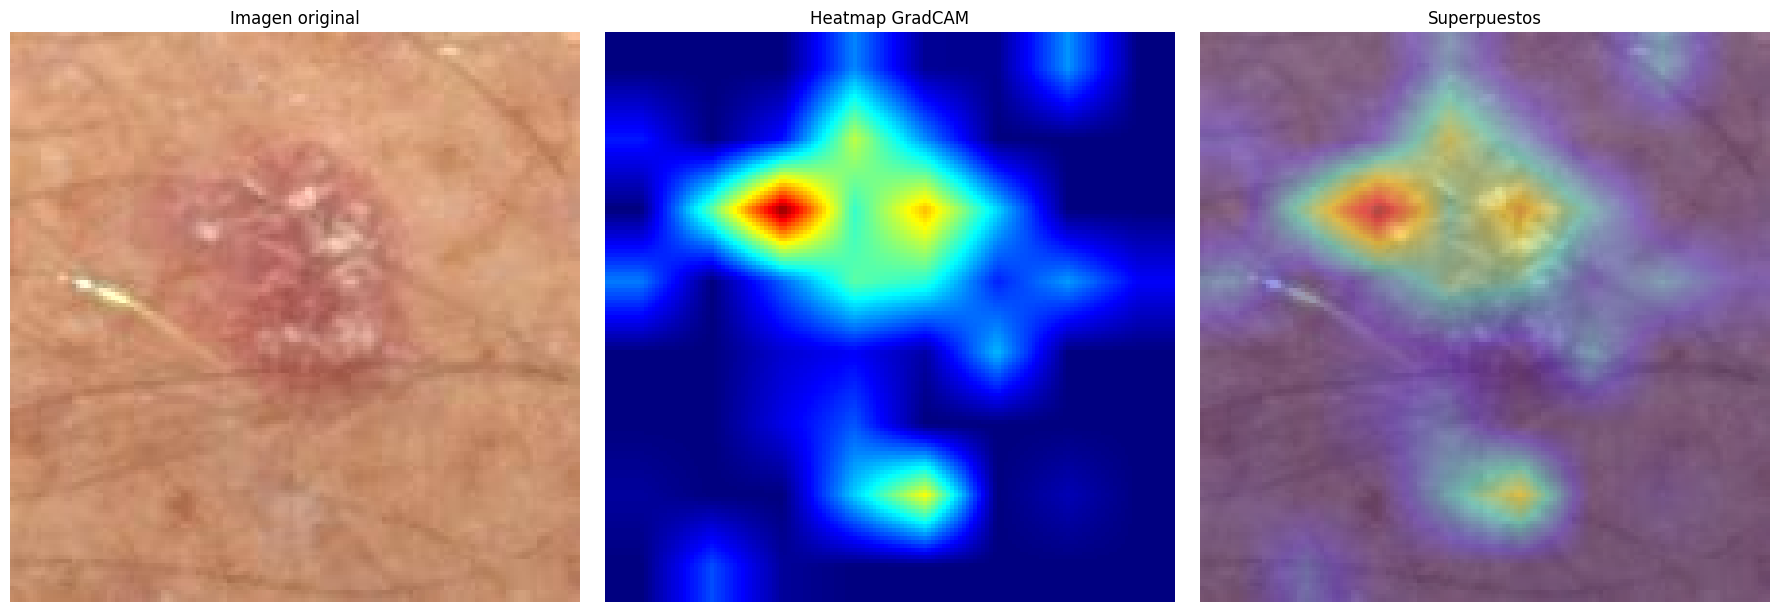

Clase predicha: 0 (Benigno)
Prob: 0.7630
Ground Truth: 1 || Prediccion incorrecta


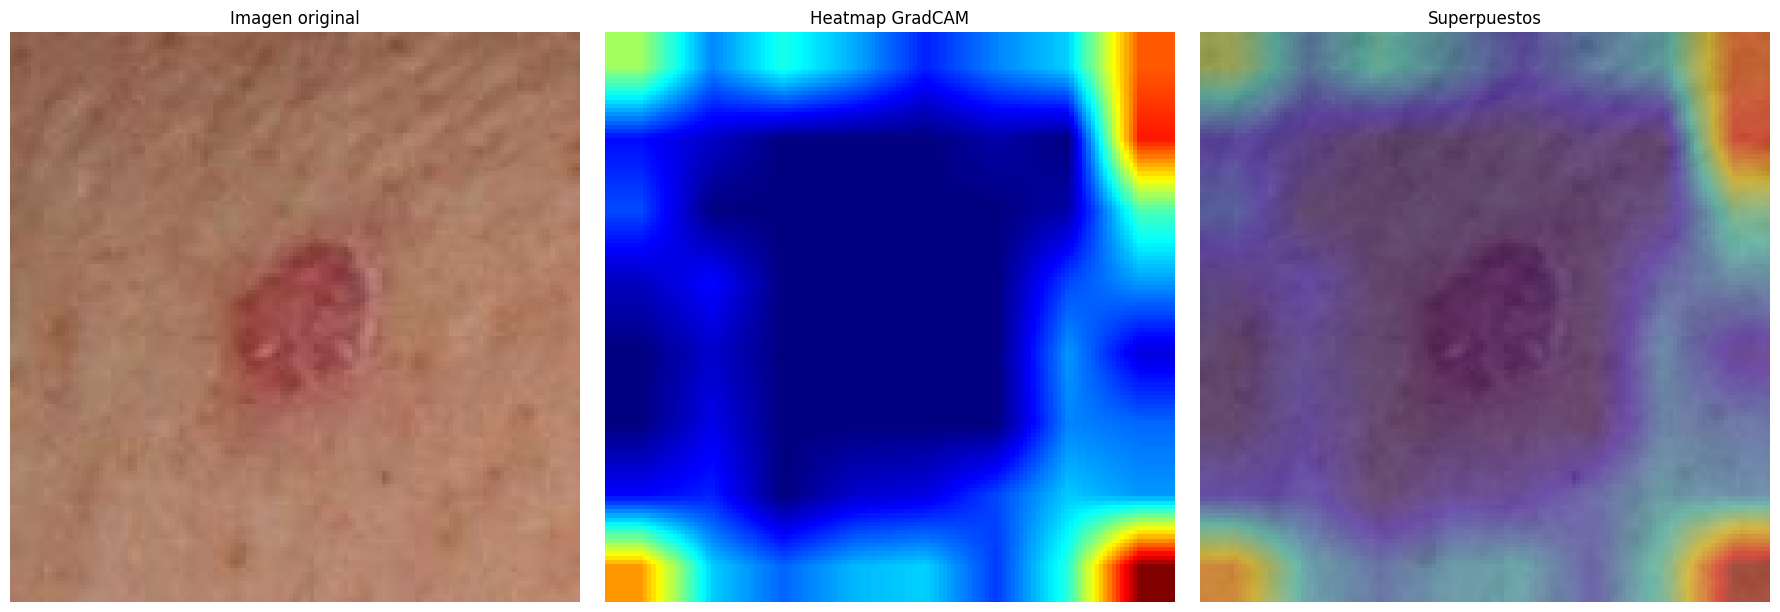

Clase predicha: 1 (Maligno)
Prob: 0.9585
Ground Truth: 1 || Prediccion correcta


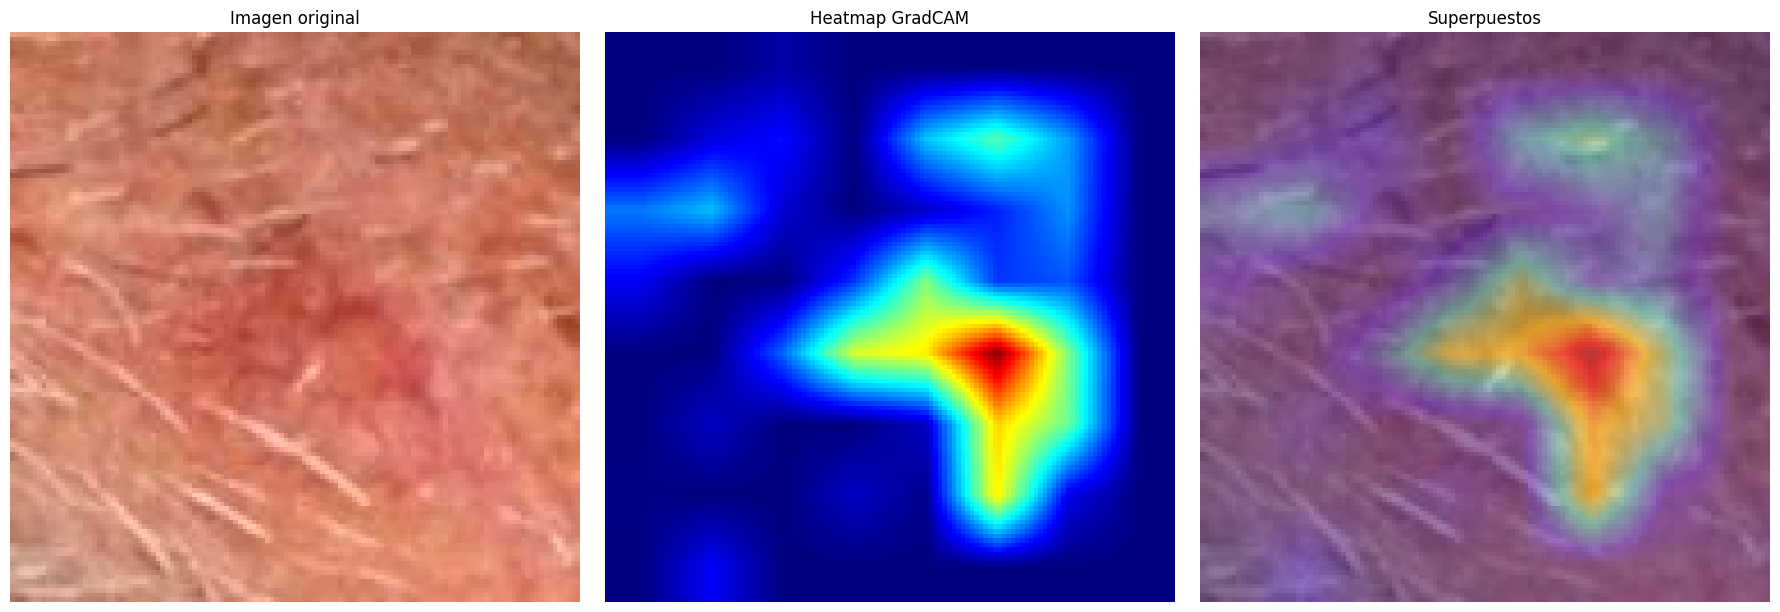

In [31]:
# Caso maligno, target = 1
print("Graficos caso maligno")

# Muestrear los primeros 3 elementos del conjunto validacion con target = 1
for i in range(0, 3):
    malignant_sample = val_df[val_df[TARGET_COL] == 1].iloc[i]
    img_path = malignant_sample[IMAGE_PATH_COL]
    true_label = malignant_sample[TARGET_COL]
    
    # Cargar imagen original
    original_img = Image.open(img_path).convert('RGB')
    original_img_np = np.array(original_img)
    
    # Aplicar transformaciones a imagen
    input_tensor = val_transforms(original_img)
    input_tensor = input_tensor.unsqueeze(0)
    
    # Graficar
    save_path = os.path.join(FIGURES_PATH, f"gradcam_maligno_{i}_")
    visualize_gradcam(explanation_model, target_layer, input_tensor, original_img_np, true_label=true_label, save_path=save_path)

Graficos caso benigno
Clase predicha: 0 (Benigno)
Prob: 0.7573
Ground Truth: 0 || Prediccion correcta


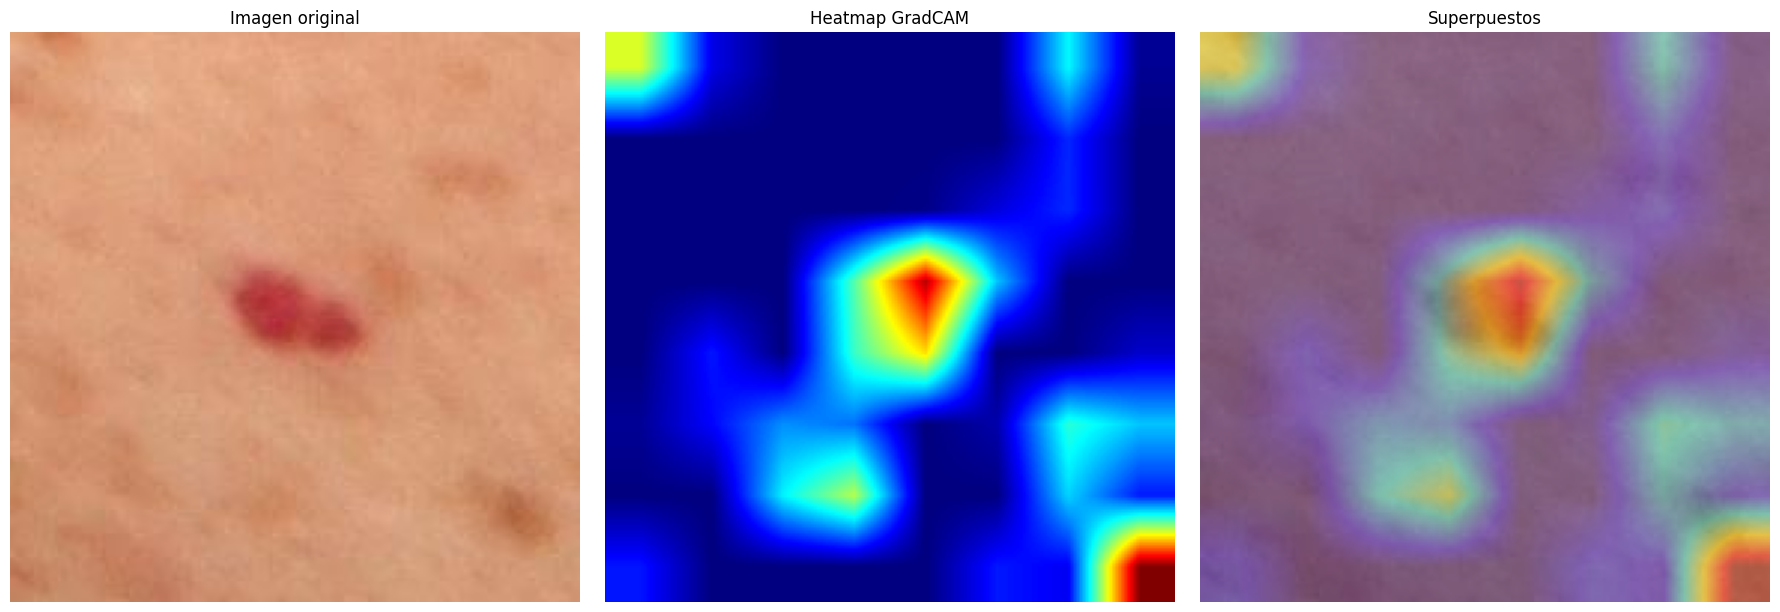

Clase predicha: 0 (Benigno)
Prob: 0.9342
Ground Truth: 0 || Prediccion correcta


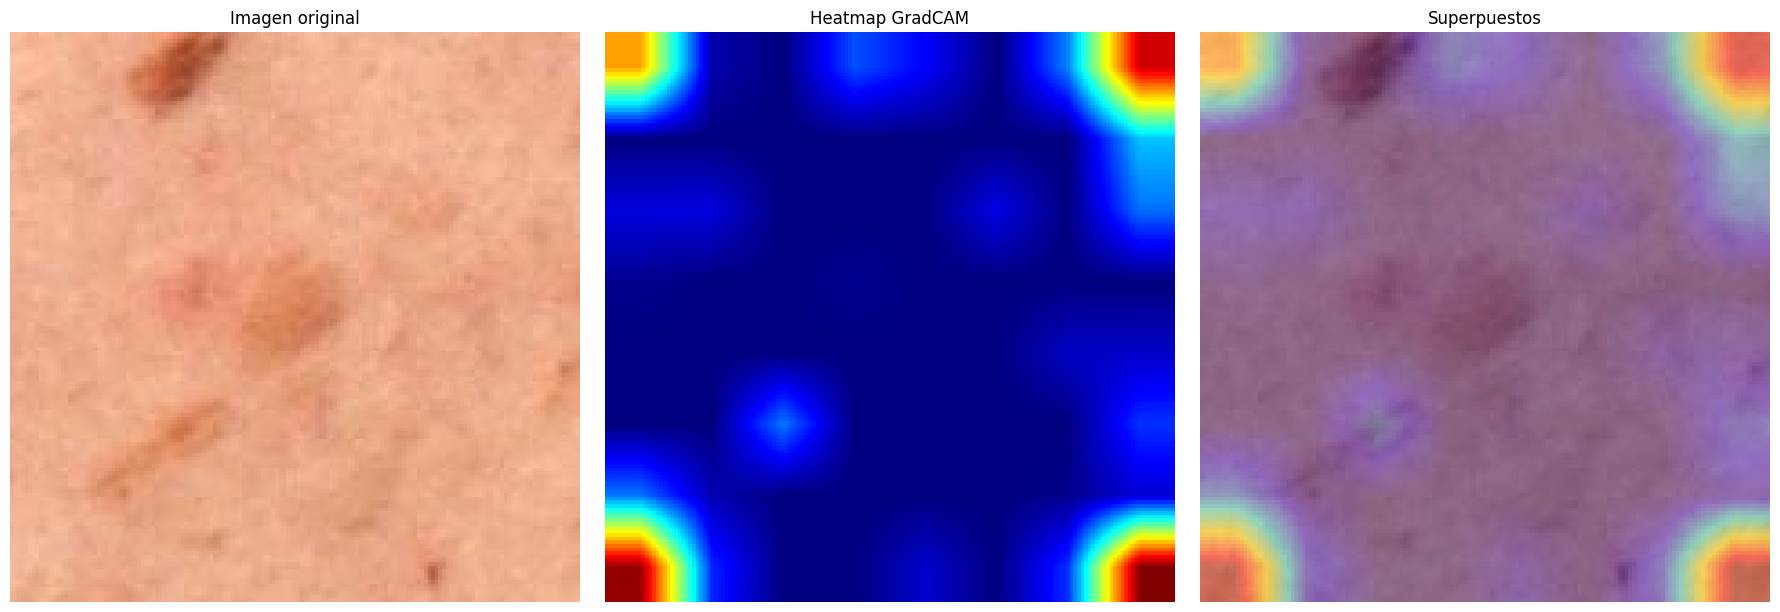

Clase predicha: 0 (Benigno)
Prob: 0.5905
Ground Truth: 0 || Prediccion correcta


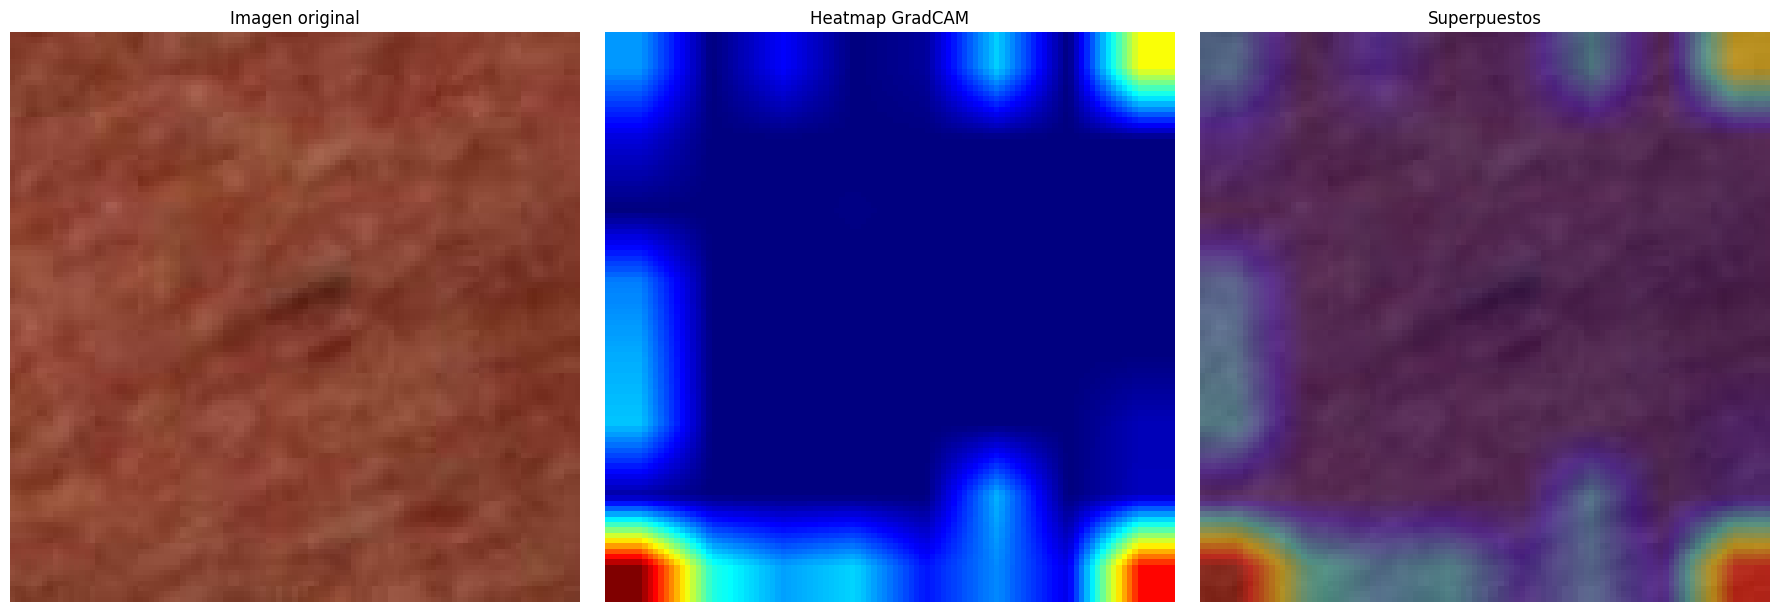

In [32]:
# Caso benigno, target = 0
print("Graficos caso benigno")

for i in range(0, 3):
    benign_sample = val_df[val_df[TARGET_COL] == 0].iloc[i]
    img_path = benign_sample[IMAGE_PATH_COL]
    true_label = benign_sample[TARGET_COL]
    
    original_img = Image.open(img_path).convert('RGB')
    original_img_np = np.array(original_img)
    input_tensor = val_transforms(original_img)
    input_tensor = input_tensor.unsqueeze(0)

    save_path = os.path.join(FIGURES_PATH, f"gradcam_benigno_{i}_")
    visualize_gradcam(explanation_model, target_layer, input_tensor, original_img_np, true_label=true_label, save_path=save_path)


# 5. Graficos de errores

In [29]:
from tqdm.auto import tqdm

# Encontrar predicciones incorrectas
tqdm.pandas()

# Funcion para computar prediccion
def get_prediction(row):
    img_path = row[IMAGE_PATH_COL]
    image = Image.open(img_path).convert('RGB')
    tensor = val_transforms(image).unsqueeze(0).to(DEVICE)
    
    with torch.no_grad():
        output = explanation_model(tensor)
    prediction = output.argmax(dim=1).item()
    return prediction

# Aplicar funcion a cada fila usando tqdm
val_df['predicted'] = val_df.progress_apply(get_prediction, axis=1)

# Falsos positivos
fp_df = val_df[(val_df['predicted'] == 1) & (val_df['target'] == 0)]

# Falsos negativos
fn_df = val_df[(val_df['predicted'] == 0) & (val_df['target'] == 1)]

print(f"N falsos positivos: {len(fp_df)}")
print(f"N falsos negativos: {len(fn_df)}")

print("Ejemplos falsos positivos")
display(fp_df.head())

print("Ejemplos falsos negativos")
display(fn_df.head())

100%|████████████████████████████████████████████████████████████████████████████| 48128/48128 [26:36<00:00, 30.15it/s]

N falsos positivos: 7847
N falsos negativos: 11
Ejemplos falsos positivos


,isic_id,target,image_path,predicted
16,ISIC_9966367,0,winner_data/images/original/ISIC_9966367.jpg,1
23,ISIC_9964030,0,winner_data/images/original/ISIC_9964030.jpg,1
38,ISIC_7230337,0,winner_data/images/original/ISIC_7230337.jpg,1
44,ISIC_7009672,0,winner_data/images/original/ISIC_7009672.jpg,1
57,ISIC_3810168,0,winner_data/images/original/ISIC_3810168.jpg,1


Ejemplos falsos negativos


,isic_id,target,image_path,predicted
1553,ISIC_2043443,1,winner_data/images/original/ISIC_2043443.jpg,0
6720,ISIC_6095295,1,winner_data/images/original/ISIC_6095295.jpg,0
11004,ISIC_8195275,1,winner_data/images/original/ISIC_8195275.jpg,0
11375,ISIC_7538059,1,winner_data/images/original/ISIC_7538059.jpg,0
17784,ISIC_4843324,1,winner_data/images/original/ISIC_4843324.jpg,0


Clase predicha: 0 (Benigno)
Prob: 0.7630
Ground Truth: 1 || Prediccion incorrecta


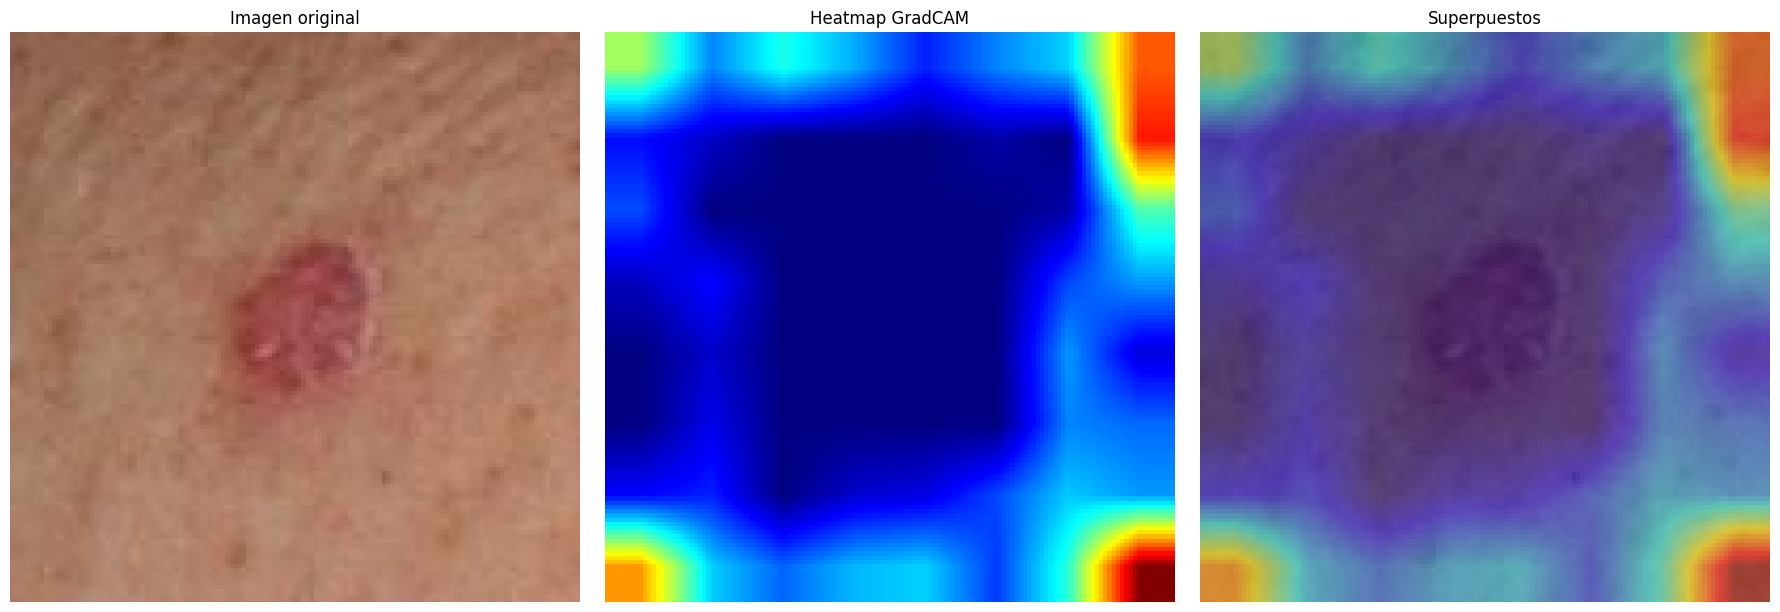

Clase predicha: 0 (Benigno)
Prob: 0.9906
Ground Truth: 1 || Prediccion incorrecta


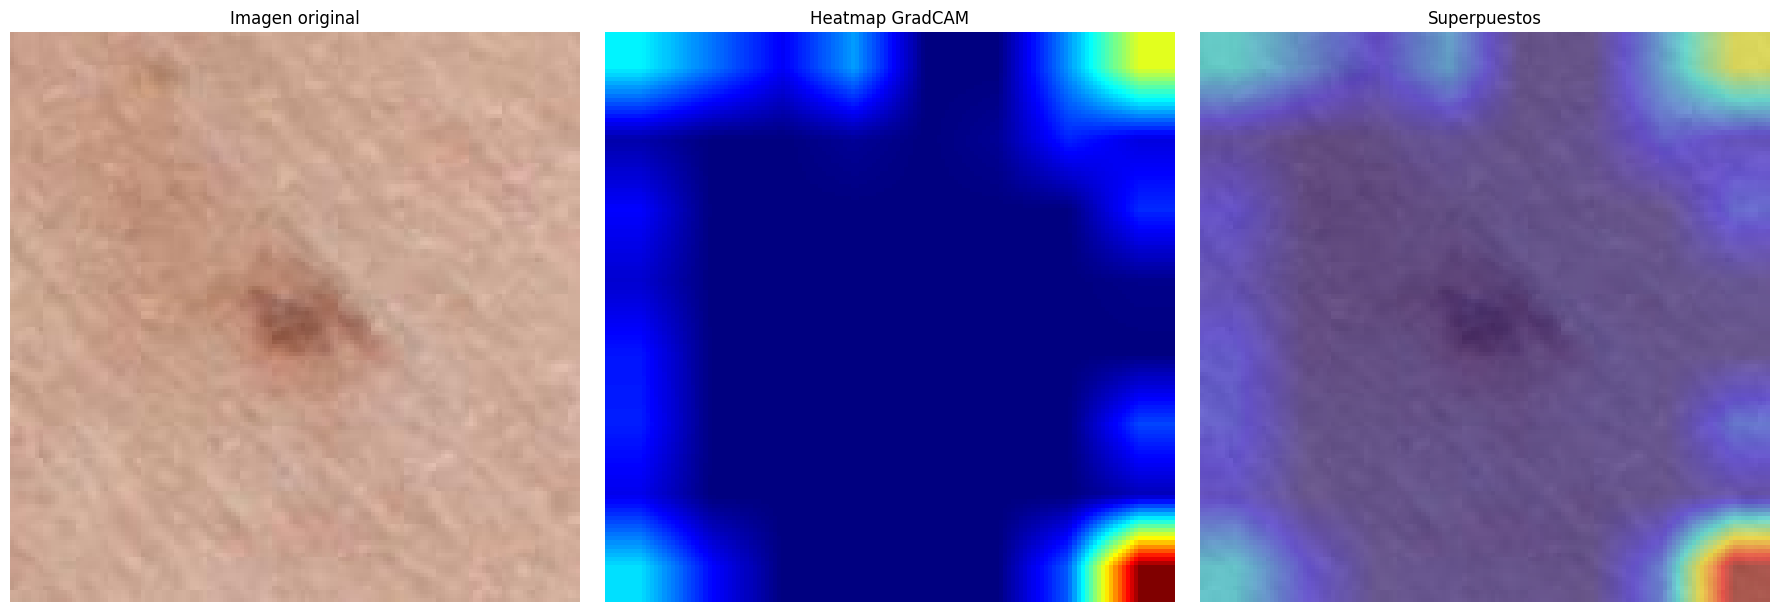

Clase predicha: 0 (Benigno)
Prob: 0.7967
Ground Truth: 1 || Prediccion incorrecta


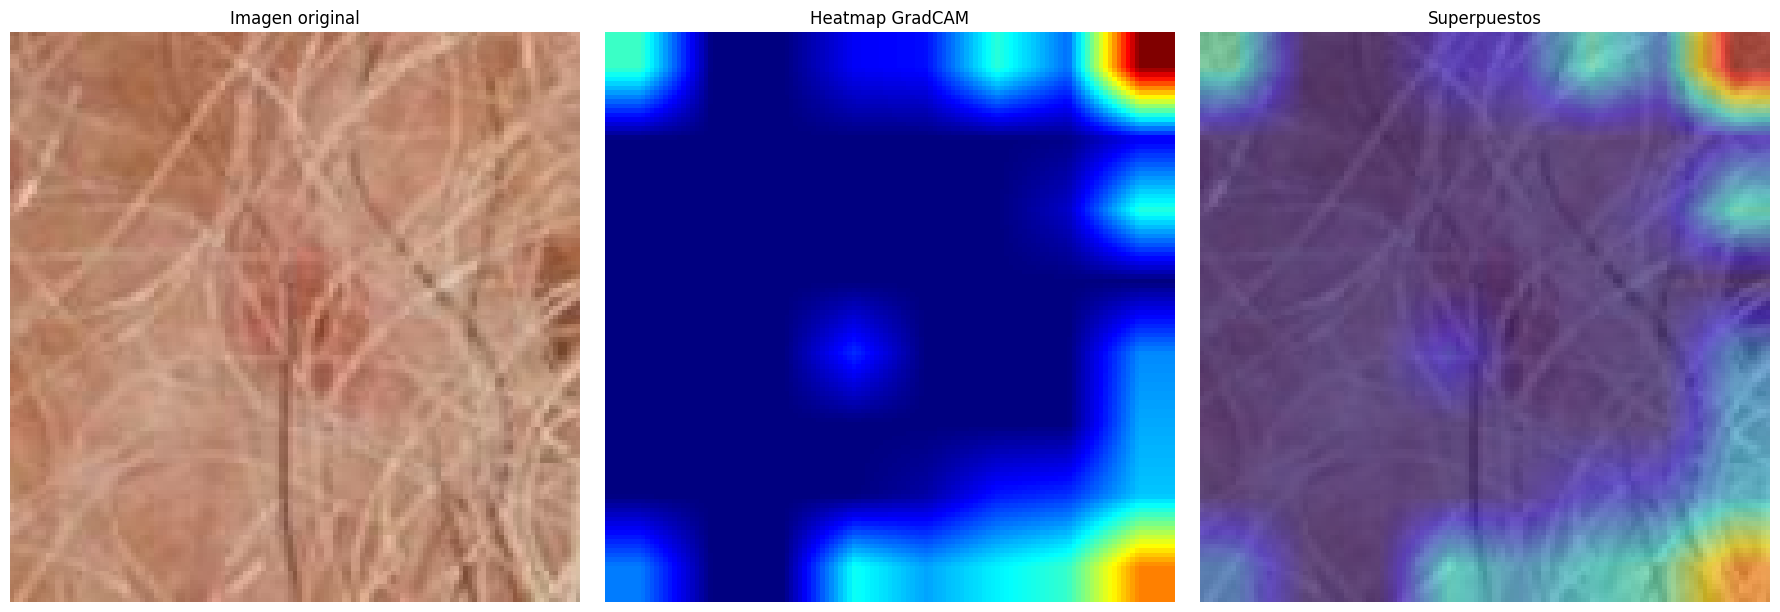

In [32]:
# Graficar error de clasificacion, falso negativo

for i in range(0, 3):
    sample_to_analyze = fn_df.iloc[i]
    
    img_path = sample_to_analyze[IMAGE_PATH_COL]
    true_label = sample_to_analyze[TARGET_COL]
    
    # Cargar imagen
    original_img = Image.open(img_path).convert('RGB')
    original_img_np = np.array(original_img)
    input_tensor = val_transforms(original_img).unsqueeze(0)
    
    # Grafico
    visualize_gradcam(explanation_model, target_layer, input_tensor, original_img_np, true_label=true_label)

Clase predicha: 1 (Maligno)
Prob: 0.6406
Ground Truth: 0 || Prediccion incorrecta


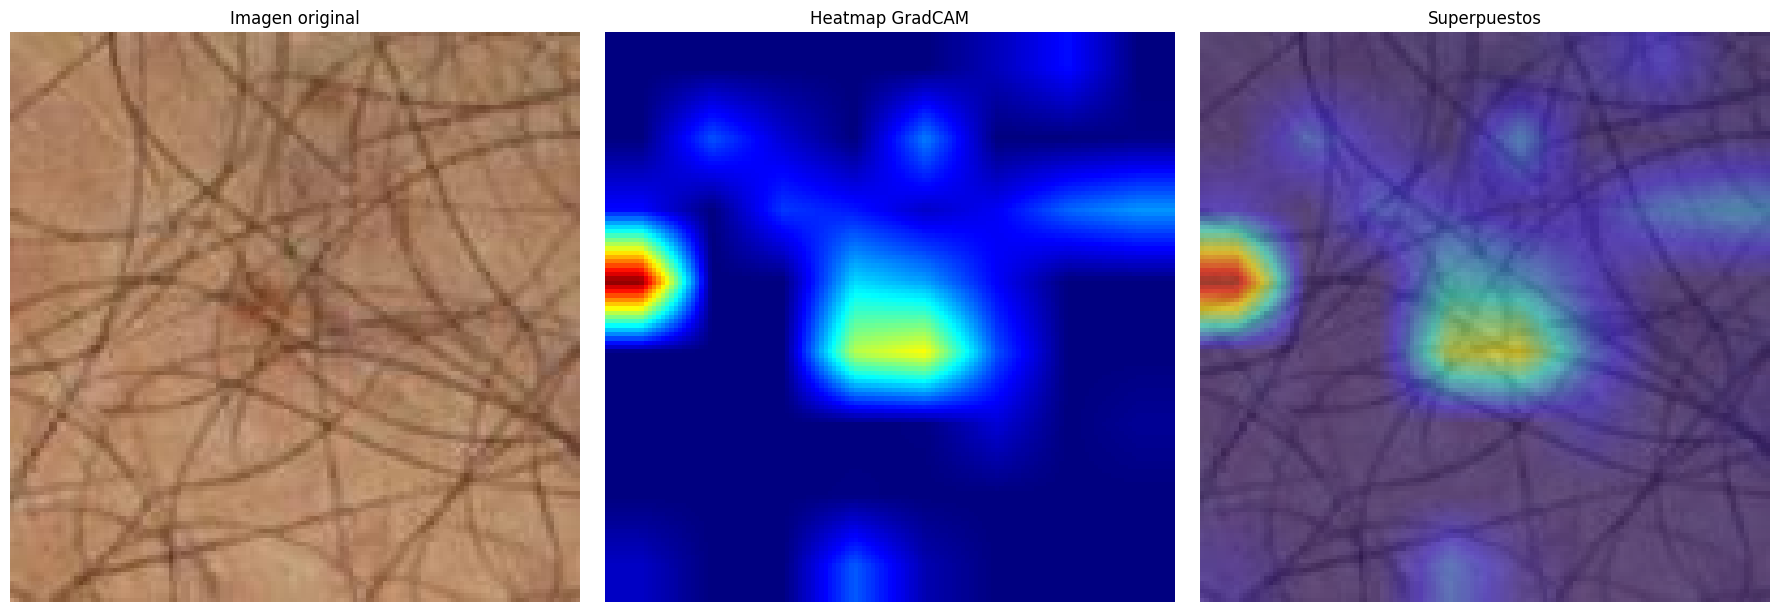

Clase predicha: 1 (Maligno)
Prob: 0.5554
Ground Truth: 0 || Prediccion incorrecta


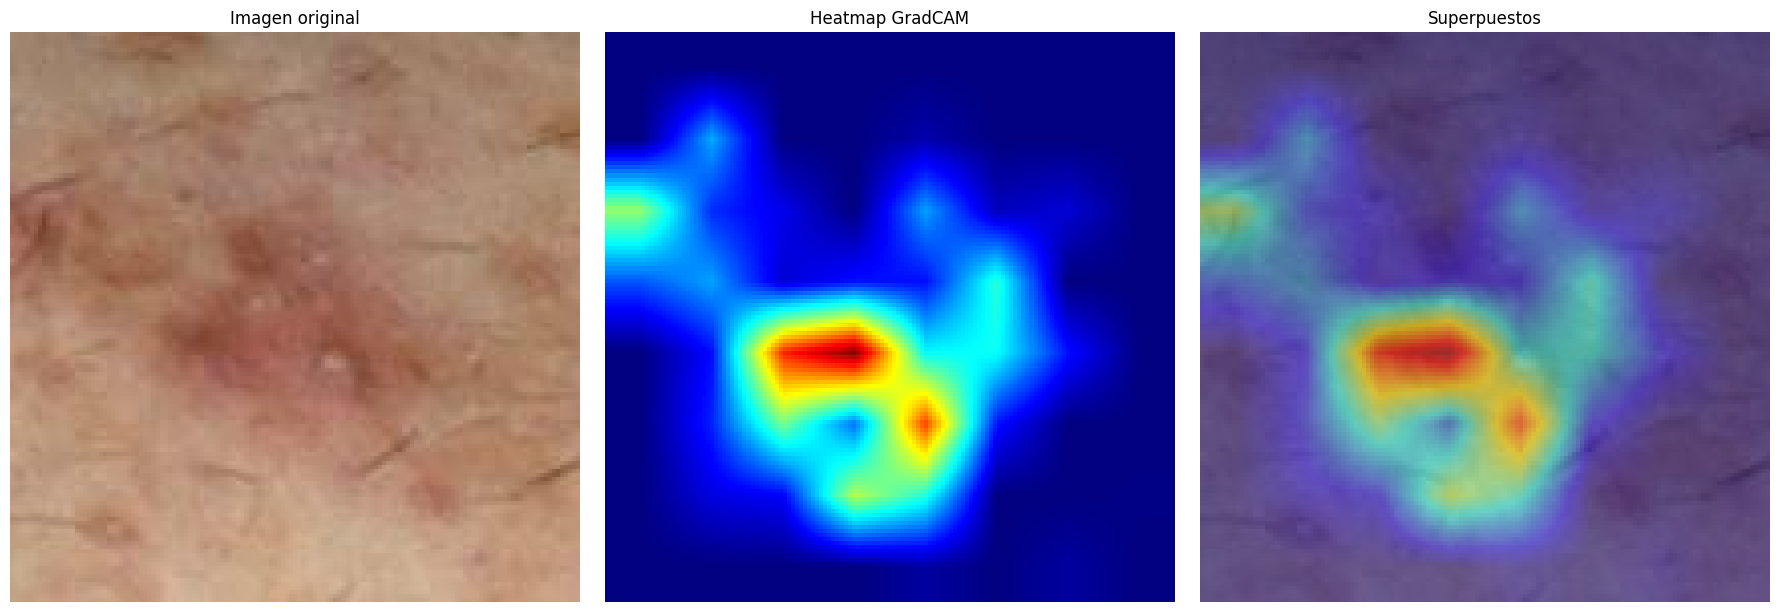

Clase predicha: 1 (Maligno)
Prob: 0.7285
Ground Truth: 0 || Prediccion incorrecta


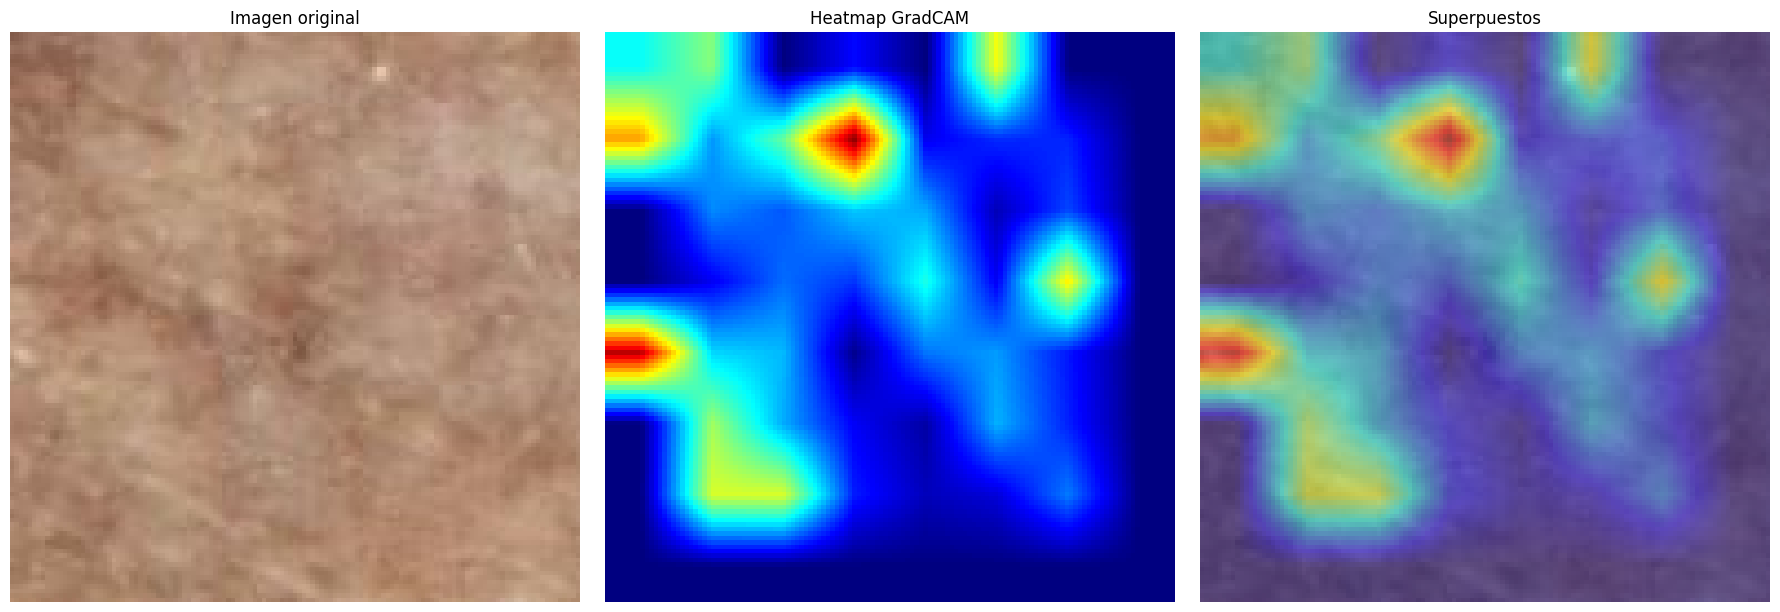

In [33]:
# Graficar falso positivo
for i in range(0, 3):
    sample_to_analyze = fp_df.iloc[i]
    
    img_path = sample_to_analyze[IMAGE_PATH_COL]
    true_label = sample_to_analyze[TARGET_COL]
    
    # Cargar imagen
    original_img = Image.open(img_path).convert('RGB')
    original_img_np = np.array(original_img)
    input_tensor = val_transforms(original_img).unsqueeze(0)
    
    # Grafico
    visualize_gradcam(explanation_model, target_layer, input_tensor, original_img_np, true_label=true_label)

# 6. Grafico de degradacion

In [37]:
from sklearn.metrics import balanced_accuracy_score, roc_auc_score
from tqdm.auto import tqdm

# Funcion de auc parcial
def calculate_custom_partial_auc(y_true, y_pred_proba_positive_class):
    y_true = np.asarray(y_true)
    y_pred_proba_positive_class = np.asarray(y_pred_proba_positive_class)

    min_tpr_threshold = 0.80
    max_fpr_threshold = abs(1 - min_tpr_threshold)
    v_gt = np.abs(y_true - 1) 
    v_pred_proba_negative_class = 1.0 - y_pred_proba_positive_class
    
    if len(np.unique(v_gt)) < 2:
        return 0.0
    
    partial_auc_scaled = roc_auc_score(v_gt, v_pred_proba_negative_class, max_fpr=max_fpr_threshold)
    true_partial_auc = 0.5 * max_fpr_threshold**2 + (partial_auc_scaled - 0.5) * (max_fpr_threshold**2)

    return true_partial_auc

# Parametros
NUM_SAMPLES_TO_TEST = 50 
PERTURBATION_STEPS = [0.0, 0.01, 0.02, 0.05, 0.10, 0.20, 0.30, 0.50]
# Reemplazar pixeles con negro
BASELINE_VALUE = 0.0

In [38]:
# Diccionario rendimiento
results = {'balanced_accuracy': [], 'partial_auc': []}

layer_gradcam = LayerGradCam(explanation_model, target_layer)

# Samplear 25 de cada clase pq dataset desbalanceado
NUM_SAMPLES_PER_CLASS = int(NUM_SAMPLES_TO_TEST / 2)

benign_samples = val_df[val_df['target'] == 0].sample(n=NUM_SAMPLES_PER_CLASS, random_state=2025)
malignant_samples = val_df[val_df['target'] == 1].sample(n=NUM_SAMPLES_PER_CLASS, random_state=2025)

# Combinar en un dataframe
val_subset = pd.concat([benign_samples, malignant_samples])
val_subset = val_subset.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"Dataset balanceado de {len(val_subset)} muestras")
print("Distribucion de clases", val_subset['target'].value_counts())

Dataset balanceado de 50 muestras
Distribucion de clases target
0    25
1    25
Name: count, dtype: int64


In [39]:
# Registrar degradacion
for percentage in tqdm(PERTURBATION_STEPS, desc="Porcentajes perturbacion"):
    
    y_true_all = []
    y_pred_probs_all = []
    
    for _, row in tqdm(val_subset.iterrows(), total=len(val_subset), leave=False, desc="Procesar imagenes"):
        img_path = row[IMAGE_PATH_COL]
        true_label = row[TARGET_COL]
        
        original_img = Image.open(img_path).convert('RGB')
        input_tensor = val_transforms(original_img).unsqueeze(0).to(DEVICE)
        
        perturbed_tensor = input_tensor.clone()

        if percentage > 0:
            attribution = layer_gradcam.attribute(input_tensor, target=true_label)

            # Agrandar heatmap para que sea igual a dim de imagen
            upsampled_attribution = torch.nn.functional.interpolate(
                attribution, size=(input_tensor.shape[2], input_tensor.shape[3]), mode='bilinear'
            )

            num_pixels_to_perturb = int(percentage * (input_tensor.shape[2] * input_tensor.shape[3]))
            
            flat_upsampled_attr = upsampled_attribution.flatten()
            _, top_indices_in_image = torch.topk(flat_upsampled_attr, num_pixels_to_perturb)
            
            flat_perturbed_tensor = perturbed_tensor.flatten()
            flat_perturbed_tensor[top_indices_in_image] = BASELINE_VALUE
            perturbed_tensor = flat_perturbed_tensor.view_as(input_tensor)

        with torch.no_grad():
            output = explanation_model(perturbed_tensor)
            probabilities = torch.nn.functional.softmax(output, dim=1)
        
        y_true_all.append(true_label)
        y_pred_probs_all.append(probabilities[0, 1].item())
    
    y_pred_class = (np.array(y_pred_probs_all) >= 0.5).astype(int)
    
    bal_acc = balanced_accuracy_score(y_true_all, y_pred_class)
    p_auc = calculate_custom_partial_auc(y_true_all, y_pred_probs_all)
    
    results['balanced_accuracy'].append(bal_acc)
    results['partial_auc'].append(p_auc)
    
    print(f"Porcentaje removido: {percentage*100:.0f}% || Bal. Accuracy: {bal_acc:.4f}, Custom Partial AUC: {p_auc:.4f}")

Porcentajes perturbacion:  12%|███████▎                                                  | 1/8 [00:01<00:12,  1.84s/it]

Porcentaje removido: 0% || Bal. Accuracy: 0.7800, Custom Partial AUC: 0.0267



Porcentajes perturbacion:  25%|██████████████▌                                           | 2/8 [00:05<00:17,  2.93s/it]

Porcentaje removido: 1% || Bal. Accuracy: 0.7400, Custom Partial AUC: 0.0233



Porcentajes perturbacion:  38%|█████████████████████▊                                    | 3/8 [00:09<00:16,  3.24s/it]

...

Porcentaje removido: 20% || Bal. Accuracy: 0.5000, Custom Partial AUC: 0.0197



Porcentajes perturbacion:  88%|██████████████████████████████████████████████████▊       | 7/8 [00:22<00:03,  3.39s/it]

Porcentaje removido: 30% || Bal. Accuracy: 0.5000, Custom Partial AUC: 0.0194



Porcentajes perturbacion: 100%|██████████████████████████████████████████████████████████| 8/8 [00:26<00:00,  3.28s/it]

Porcentaje removido: 50% || Bal. Accuracy: 0.4800, Custom Partial AUC: 0.0194


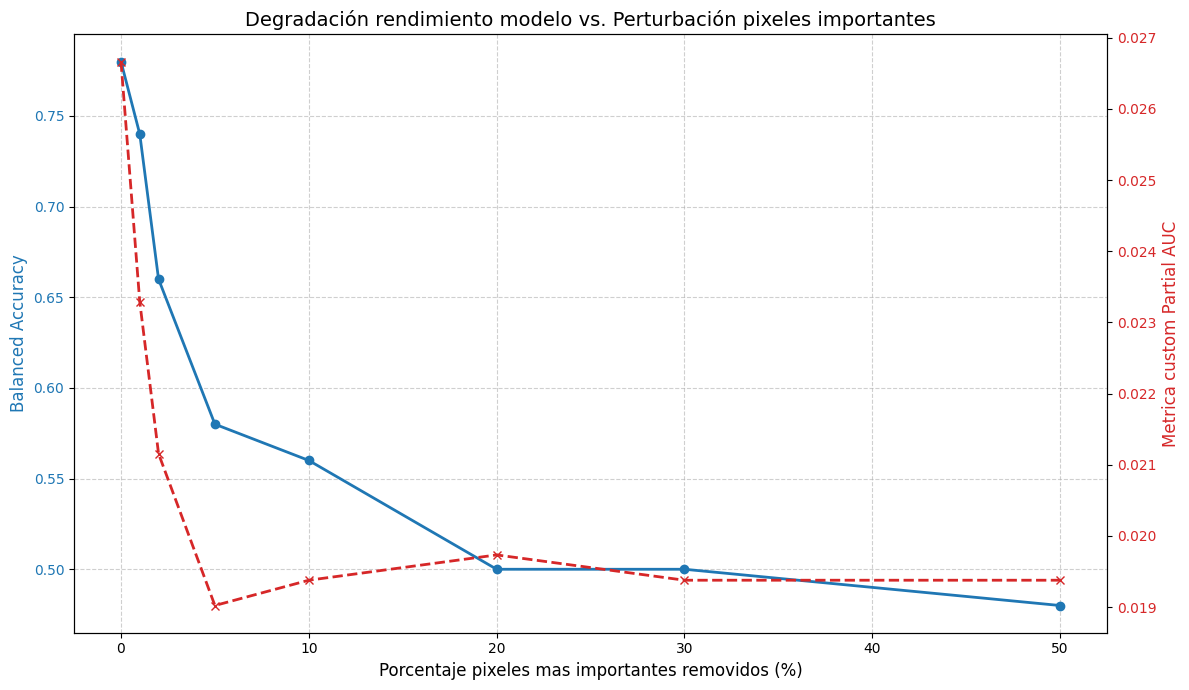

In [41]:
# Graficos de degradacion
fig, ax1 = plt.subplots(figsize=(12, 7))

x_axis = np.array(PERTURBATION_STEPS) * 100

# Eje balanced accuracy
color = 'tab:blue'
ax1.set_xlabel('Porcentaje pixeles mas importantes removidos (%)', fontsize=12)
ax1.set_ylabel('Balanced Accuracy', color=color, fontsize=12)
ax1.plot(x_axis, results['balanced_accuracy'], color=color, marker='o', linestyle='-', linewidth=2, label='Balanced Accuracy')
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, linestyle='--', alpha=0.6)

# Eje para partial auc
ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Metrica custom Partial AUC', color=color, fontsize=12)
ax2.plot(x_axis, results['partial_auc'], color=color, marker='x', linestyle='--', linewidth=2, label='Metrica custom Partial AUC')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Degradación rendimiento modelo vs. Perturbación pixeles importantes', fontsize=14)
fig.tight_layout()
save_path = os.path.join(FIGURES_PATH, 'degradacion_rendimiento.pdf')
fig.savefig(save_path, bbox_inches='tight')
plt.show()